# Cylinder Stroke Time Series — ARIMA Analysis

This notebook walks through ARIMA modelling of the cylinder stroke data from `cylinder_strokes.csv`.

**What we're doing:** Each cylinder actuates thousands of times per day. We want to know:
- Is it getting slower over time? (trend)
- Can we predict tomorrow's mean duration?
- Are there anomalies in the slow-stroke rate?

**How to use this notebook:**
1. Run **Cell 1** (imports) and **Cell 2** (load data)
2. Run **Cell 3** (the wrapper functions)
3. Jump to any analysis cell and change the parameters at the top
4. Run `show_results(result)` to get full interpretable output


## Cell 1 — Imports

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import matplotlib.dates as mdates
from matplotlib.patches import FancyBboxPatch
import matplotlib.ticker as mticker

from pmdarima import auto_arima
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from sklearn.metrics import mean_absolute_error, mean_squared_error

plt.rcParams.update({
    "figure.facecolor":  "white",
    "axes.facecolor":    "#F8F8F6",
    "axes.grid":         True,
    "grid.color":        "#E0DED6",
    "grid.linewidth":    0.6,
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "font.family":       "sans-serif",
    "axes.titlesize":    12,
    "axes.labelsize":    11,
    "xtick.labelsize":   9,
    "ytick.labelsize":   9,
})

print("✓  All imports ready")


✓  All imports ready


## Cell 2 — Load & inspect the raw data

In [2]:
# ── CONFIG ── change CSV_PATH if your file is elsewhere
CSV_PATH = "./datasets/cylinder_strokes.csv"

df_raw = pd.read_csv(CSV_PATH)
df_raw["date"]     = pd.to_datetime(df_raw["date"])
df_raw["datetime"] = df_raw["date"] + pd.to_timedelta(df_raw["t_start_ms"], unit="ms")

print(f"Loaded  : {len(df_raw):,} rows")
print(f"Dates   : {df_raw['date'].min().date()} → {df_raw['date'].max().date()}  ({df_raw['date'].nunique()} days)")
print(f"Cylinders: {df_raw['cylinder'].unique().tolist()}")
print()

# Quick summary table
summary = (df_raw.groupby(["cylinder","direction"])["duration_ms"]
           .agg(n="count", mean="mean", std="std",
                p5=lambda x: x.quantile(0.05),
                p95=lambda x: x.quantile(0.95))
           .round(1))
print("=== Stroke summary per (cylinder, direction) ===")
display(summary)


Loaded  : 557,258 rows
Dates   : 2026-02-02 → 2026-03-09  (35 days)
Cylinders: ['Lifting', 'Middle', 'Front_barrier', 'Rear_barrier']

=== Stroke summary per (cylinder, direction) ===


n   mean    std     p5    p95
cylinder      direction                                    
Front_barrier extend      60755  134.7  217.9   62.0  620.0
              retract    120846   96.4   95.9   46.0  233.0
Lifting       extend      61546  146.6  166.1   93.0  606.0
              retract     63600  123.6  150.2   78.0  537.0
Middle        extend      61614  169.3  176.4  109.0  658.0
              retract     63499  124.0  150.7   78.0  546.0
Rear_barrier  extend      62874  132.4  155.9   78.0  564.0
              retract     62524  208.2  172.2  141.0  685.0

## Cell 3 — Core functions

Three functions you'll call throughout the notebook:
- `build_series(...)` — aggregate raw strokes to a regular time series at your chosen granularity
- `run_arima(...)` — fit ARIMA and return a results dict
- `show_results(...)` — produce all interpretable plots and plain-English explanations


In [24]:
# ═══════════════════════════════════════════════════════════════════
# build_series — aggregate raw event log → regular time series
# ═══════════════════════════════════════════════════════════════════

def build_series(
    cylinder:    str  = "Middle",
    direction:   str  = "extend",
    metric:      str  = "mean_ms",
    granularity: str  = "hourly",      # "minutely" | "hourly" | "daily"
    fill_gaps:   bool = True,          # fill missing periods with interpolation
    df:          pd.DataFrame = None,
) -> pd.Series:
    """
    Collapse raw stroke records into a regular time series.

    Parameters
    ----------
    cylinder    : "Lifting" | "Middle" | "Front_barrier" | "Rear_barrier"
    direction   : "extend" | "retract"
    metric      : what to measure each period
                  "mean_ms"   → mean stroke duration  (main trend signal)
                  "std_ms"    → within-period variability
                  "p95_ms"    → 95th-percentile duration  (slow-stroke severity)
                  "slow_pct"  → % of strokes > 500 ms    (anomaly rate)
    granularity : time resolution
                  "daily"    →  35 points  — one per calendar day
                  "hourly"   → ~629 points — one per active hour  [DEFAULT]
                  "minutely" → ~26,773 pts — one per active minute (sparse!)
    fill_gaps   : whether to interpolate missing periods linearly

    Returns
    -------
    pd.Series indexed by datetime, name = "cylinder__direction__metric__granularity"
    """
    _df = df if df is not None else df_raw

    sub = _df[(_df["cylinder"] == cylinder) & (_df["direction"] == direction)].copy()
    if len(sub) == 0:
        raise ValueError(f"No data for cylinder='{cylinder}', direction='{direction}'")

    freq_map = {"daily": "D", "hourly": "h", "minutely": "min"}
    if granularity not in freq_map:
        raise ValueError(f"granularity must be one of {list(freq_map)}")
    freq = freq_map[granularity]

    sub["_bin"] = sub["datetime"].dt.floor(freq)

    agg_map = {
        "mean_ms":   ("duration_ms", "mean"),
        "std_ms":    ("duration_ms", "std"),
        "p95_ms":    ("duration_ms", lambda x: x.quantile(0.95)),
        "slow_pct":  ("duration_ms", lambda x: (x > 500).mean() * 100),
    }
    if metric not in agg_map:
        raise ValueError(f"metric must be one of {list(agg_map)}")

    col, agg_fn = agg_map[metric]
    series = sub.groupby("_bin")[col].agg(agg_fn)
    series.index.name = "datetime"
    series.name = f"{cylinder}__{direction}__{metric}__{granularity}"

    if fill_gaps:
        full_idx = pd.date_range(series.index.min(), series.index.max(), freq=freq)
        series = series.reindex(full_idx)
        pct_missing = series.isna().mean() * 100
        if pct_missing > 0:
            series = series.interpolate("time")

    return series


# ═══════════════════════════════════════════════════════════════════
# run_arima — fit ARIMA and return a results bundle
# ═══════════════════════════════════════════════════════════════════

def run_arima(
    cylinder:    str   = "Middle",
    direction:   str   = "extend",
    metric:      str   = "mean_ms",
    granularity: str   = "hourly",
    train_series: pd.Series | None = None,
    test_series: pd.Series | None = None,
    test_frac:   float = 0.15,
    # ── auto_arima passthrough (all optional) ──────────────────────
    start_p:     int   = 8,
    start_q:     int   = 8,
    max_p:       int   = 10,
    max_q:       int   = 10,
    max_d:       int   = 10,
    seasonal:    bool  = False,
    m:           int   = 1,
    information_criterion: str = "aic",
    stepwise:    bool  = True,
    # ───────────────────────────────────────────────────────────────
    verbose:     bool  = True,
    df= df_raw
) -> dict:
    """
    Fit ARIMA to a cylinder stroke time series and return a results bundle.

    Parameters
    ----------
    cylinder / direction / metric / granularity
        Passed straight to build_series(). See that docstring.

    test_frac : float
        Fraction of data to hold out as test set. Default 0.15 (15%).
        e.g. for 629 hourly points → ~94 test points (~4 days).

    --- auto_arima passthrough (all optional, sensible defaults set) ---
    start_p, start_q : starting orders for the search
    max_p, max_q, max_d : upper bounds on the search space
    seasonal    : fit SARIMA seasonal terms (slower, needs more data)
    m           : seasonal period (e.g. 24 for hourly with daily seasonality)
    information_criterion : "aic" | "bic" | "hqic" — model selection metric
    stepwise    : True = fast heuristic search; False = exhaustive grid search

    verbose : bool
        Print search log and model summary.

    Returns
    -------
    dict with keys:
        series, train, test,
        model,          ← fitted pmdarima ARIMA object
        forecast,       ← pd.Series of point predictions, aligned to test.index
        conf_int,       ← np.ndarray (n_test, 2) — lower/upper 95% CI
        mae, rmse, mape,
        order,          ← (p, d, q) chosen
        seasonal_order, ← (P, D, Q, m) if seasonal, else None
        unit,           ← "%" or "ms"
        granularity
    """
    # series = build_series(cylinder, direction, metric, granularity,df=df)
    # unit   = "%" if metric == "slow_pct" else "ms"

    # n_test = max(5, int(len(series) * test_frac))
    # train  = series.iloc[:-n_test]
    # test   = series.iloc[-n_test:]


    series = build_series(cylinder, direction, metric, granularity, df=df)
    unit   = "%" if metric == "slow_pct" else "ms"

    if train_series is not None and test_series is not None:
        train = train_series
        test  = test_series
    else:
        n_test = max(5, int(len(series) * test_frac))
        train  = series.iloc[:-n_test]
        test   = series.iloc[-n_test:]


    if verbose:
        print(f"\n{'='*62}")
        print(f"  {series.name}")
        print(f"  Train: {train.index[0]} → {train.index[-1]}  ({len(train)} pts)")
        print(f"  Test : {test.index[0]}  → {test.index[-1]}  ({len(test)} pts)")
        print(f"  Range: {series.min():.2f} – {series.max():.2f} {unit}")
        print(f"{'='*62}\n")

    model = auto_arima(
        train.values,
        start_p=start_p, start_q=start_q,
        max_p=max_p, max_q=max_q, max_d=max_d,
        seasonal=seasonal, m=m,
        information_criterion=information_criterion,
        stepwise=stepwise,
        error_action="ignore",
        suppress_warnings=True,
        trace=verbose,
    )

    if verbose:
        print("\n" + str(model.summary()))

    raw_fc, conf_int = model.predict(n_periods=len(test), return_conf_int=True)
    fc_arr   = raw_fc.values if hasattr(raw_fc, "values") else np.asarray(raw_fc)
    forecast = pd.Series(fc_arr, index=test.index, name="forecast")

    mae  = mean_absolute_error(test.values, forecast.values)
    rmse = np.sqrt(mean_squared_error(test.values, forecast.values))
    mape = np.mean(np.abs((test.values - forecast.values) / (test.values + 1e-9))) * 100

    if verbose:
        print(f"\nOrder  : ARIMA{model.order}"
              + (f" × SARIMA{model.seasonal_order}" if seasonal else ""))
        print(f"MAE    : {mae:.3f} {unit}")
        print(f"RMSE   : {rmse:.3f} {unit}")
        print(f"MAPE   : {mape:.2f}%")

    return dict(
        series=series, train=train, test=test,
        model=model, forecast=forecast, conf_int=conf_int,
        mae=mae, rmse=rmse, mape=mape,
        order=model.order,
        seasonal_order=model.seasonal_order if seasonal else None,
        unit=unit, granularity=granularity,
    )


# ═══════════════════════════════════════════════════════════════════
# show_results — full interpretable output
# ═══════════════════════════════════════════════════════════════════

def _plain_english(r: dict) -> str:
    """Generate a plain-English interpretation of ARIMA results."""
    p, d, q = r["order"]
    unit     = r["unit"]
    mae      = r["mae"]
    mape     = r["mape"]
    series   = r["series"]
    name     = series.name

    # Stationarity from d
    if d == 0:
        stationarity = ("The series is STATIONARY — it oscillates around a stable mean. "
                        "No long-term drift was detected, so ARIMA can model it as-is.")
    elif d == 1:
        stationarity = ("The series is NON-STATIONARY — it has a trend (drift up or down). "
                        "ARIMA differenced it once (d=1) to remove the trend before modelling.")
    else:
        stationarity = (f"The series needed {d} rounds of differencing to become stationary, "
                        "suggesting a strong or double trend.")

    # AR and MA interpretation
    ar_msg = (f"p={p}: The model uses the last {p} observation(s) to predict the next one."
              if p > 0 else "p=0: No autoregressive terms — past values don't directly predict the next.")
    ma_msg = (f"q={q}: The model corrects for the last {q} prediction error(s)."
              if q > 0 else "q=0: No moving-average terms — past errors don't correct future predictions.")

    # Forecast quality
    if mape < 3:
        quality = f"Excellent — MAPE of {mape:.1f}% means predictions are within ~{mape:.1f}% of the true value."
    elif mape < 8:
        quality = f"Good — MAPE of {mape:.1f}%. Predictions are reasonably close; MAE={mae:.1f}{unit} on average."
    elif mape < 20:
        quality = (f"Moderate — MAPE of {mape:.1f}%. The model captures the general direction "
                   f"but individual points vary by ~{mae:.1f}{unit}.")
    else:
        quality = (f"Weak — MAPE of {mape:.1f}%. This series may be too noisy or too short "
                   "for ARIMA to model well. Consider more data or a different metric.")

    trend_dir = ""
    if d >= 1:
        slope = series.iloc[-1] - series.iloc[0]
        trend_dir = (f" The overall trend over the data window is "
                     f"{'UPWARD ↑' if slope > 0 else 'DOWNWARD ↓'} "
                     f"(+{slope:.1f}{unit} from start to end)." if slope > 0
                     else f" (−{abs(slope):.1f}{unit} from start to end).")

    lines = [
        f"━━━  Plain-English Interpretation  ━━━",
        f"",
        f"Series  : {name}",
        f"",
        f"[Stationarity]  {stationarity}{trend_dir}",
        f"",
        f"[Model order]  ARIMA({p},{d},{q})",
        f"  {ar_msg}",
        f"  {ma_msg}",
        f"",
        f"[Forecast accuracy]  {quality}",
        f"  MAE  = {mae:.3f} {unit}   (average absolute miss)",
        f"  RMSE = {r['rmse']:.3f} {unit}  (penalises large misses more)",
        f"  MAPE = {mape:.2f}%         (percentage miss, scale-free)",
        f"",
        f"[What to do next]",
    ]
    if d == 0 and p == 0 and q == 0:
        lines.append("  auto_arima chose a constant mean model (white noise). This means")
        lines.append("  the series has no detectable structure at this granularity.")
        lines.append("  Try: force d=1, use a finer granularity, or model a different metric.")
    elif d >= 1:
        lines.append("  A trend exists. Watch for the trend continuing in future data.")
        lines.append("  The 95% CI widens over time — further-ahead forecasts are less certain.")
    else:
        lines.append("  The series is stable. ARIMA should give reliable near-term forecasts.")
    return "\n".join(lines)


def show_results(r: dict, figsize=(15, 13)):
    """
    Produce a full interpretable output for an ARIMA result:
      1. Plain-English explanation (printed)
      2. 5-panel diagnostic figure:
         - Full series with train/test/forecast
         - Zoom: forecast vs actuals
         - Residuals over time
         - Residual histogram (should be bell-shaped)
         - Residual ACF (bars should be inside the blue band)
    """
    print(_plain_english(r))

    series   = r["series"]
    train    = r["train"]
    test     = r["test"]
    forecast = r["forecast"]
    ci       = r["conf_int"]
    model    = r["model"]
    unit     = r["unit"]
    p, d, q  = r["order"]

    residuals = pd.Series(model.resid(), index=train.index)

    fig = plt.figure(figsize=figsize)
    fig.suptitle(
        f"ARIMA({p},{d},{q})  ·  {series.name}",
        fontsize=13, fontweight="500", y=0.99
    )
    gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.55, wspace=0.32)

    # ── Panel 1: Full series ─────────────────────────────────────────
    ax1 = fig.add_subplot(gs[0, :])
    ax1.plot(train.index, train.values, color="#378ADD", lw=1.2, label="Train", alpha=0.9)
    ax1.plot(test.index,  test.values,  color="#1D9E75", lw=1.5, label="Actual (test)", zorder=3)
    ax1.plot(forecast.index, forecast.values, "--", color="#D85A30", lw=2,
             label="Forecast", zorder=4)
    ax1.fill_between(forecast.index, ci[:, 0], ci[:, 1],
                     color="#D85A30", alpha=0.12, label="95% confidence interval")
    ax1.axvline(test.index[0], color="#888", lw=0.8, linestyle=":")
    ax1.text(test.index[0], ax1.get_ylim()[1] if ax1.get_ylim()[1] != 0 else 1,
             " ← test starts", fontsize=8, color="#888", va="top")
    ax1.set_ylabel(f"Duration ({unit})")
    ax1.set_title("Full series — where does the model forecast vs reality?", fontsize=11)
    ax1.legend(fontsize=8, ncol=4, framealpha=0.7)

    # ── Panel 2: Forecast zoom ───────────────────────────────────────
    ax2 = fig.add_subplot(gs[1, 0])
    ax2.plot(test.index, test.values,     "o-", color="#1D9E75", lw=1.5, ms=4, label="Actual")
    ax2.plot(test.index, forecast.values, "s--", color="#D85A30", lw=1.5, ms=4, label="Forecast")
    ax2.fill_between(test.index, ci[:, 0], ci[:, 1], color="#D85A30", alpha=0.12)
    ax2.set_title("Forecast vs actual (test window)", fontsize=11)
    ax2.set_ylabel(f"Duration ({unit})")
    ax2.legend(fontsize=9)
    info = f"MAE={r['mae']:.2f}{unit}\nRMSE={r['rmse']:.2f}{unit}\nMAPE={r['mape']:.1f}%"
    ax2.text(0.03, 0.97, info, transform=ax2.transAxes, fontsize=8.5,
             va="top", bbox=dict(boxstyle="round,pad=0.4", fc="white", alpha=0.8))
    ax2.text(0.03, 0.03,
             "✓ Good if orange dashes follow green circles\n"
             "✓ CI bands should just contain the actual line",
             transform=ax2.transAxes, fontsize=7.5, color="#555", va="bottom",
             bbox=dict(boxstyle="round,pad=0.3", fc="#FFFBE6", alpha=0.85))

    # ── Panel 3: Residuals over time ─────────────────────────────────
    ax3 = fig.add_subplot(gs[1, 1])
    ax3.plot(residuals.index, residuals.values, color="#534AB7", lw=0.9, alpha=0.8)
    ax3.axhline(0, color="#888", lw=0.8, linestyle="--")
    ax3.fill_between(residuals.index, residuals.values, 0,
                     where=residuals.values > 0, color="#534AB7", alpha=0.12)
    ax3.fill_between(residuals.index, residuals.values, 0,
                     where=residuals.values < 0, color="#D85A30", alpha=0.12)
    ax3.set_title("Residuals over time (training errors)", fontsize=11)
    ax3.set_ylabel(f"Error ({unit})")
    ax3.text(0.03, 0.03,
             "✓ Should look like random noise — no pattern\n"
             "✗ Funnel shape = heteroskedasticity\n"
             "✗ Waves = missing seasonality",
             transform=ax3.transAxes, fontsize=7.5, color="#555", va="bottom",
             bbox=dict(boxstyle="round,pad=0.3", fc="#FFFBE6", alpha=0.85))

    # ── Panel 4: Residual histogram ───────────────────────────────────
    ax4 = fig.add_subplot(gs[2, 0])
    ax4.hist(residuals.values, bins=25, color="#534AB7", alpha=0.65,
             edgecolor="white", lw=0.4, density=True)
    # overlay a normal curve for reference
    mu, sig = residuals.mean(), residuals.std()
    x_norm = np.linspace(residuals.min(), residuals.max(), 200)
    from scipy.stats import norm
    ax4.plot(x_norm, norm.pdf(x_norm, mu, sig), color="#D85A30", lw=1.5,
             linestyle="--", label="Normal reference")
    ax4.axvline(0, color="#888", lw=1, linestyle="--")
    ax4.set_title("Residual distribution (should be bell-shaped)", fontsize=11)
    ax4.set_xlabel(f"Residual ({unit})")
    ax4.set_ylabel("Density")
    ax4.legend(fontsize=8)
    ax4.text(0.03, 0.97,
             "✓ Bars should follow the orange dashed bell curve\n"
             "✓ Peak centred at 0 = unbiased predictions",
             transform=ax4.transAxes, fontsize=7.5, color="#555", va="top",
             bbox=dict(boxstyle="round,pad=0.3", fc="#FFFBE6", alpha=0.85))

    # ── Panel 5: Residual ACF ─────────────────────────────────────────
    ax5 = fig.add_subplot(gs[2, 1])
    max_lags = min(30, len(residuals) // 4)
    plot_acf(residuals.values, lags=max_lags, ax=ax5,
             color="#534AB7", alpha=0.05, zero=False)
    ax5.axhline(0, color="#888", lw=0.5)
    ax5.set_title("Residual autocorrelation (ACF)", fontsize=11)
    ax5.set_xlabel("Lag")
    ax5.set_ylabel("Correlation")
    ax5.text(0.03, 0.97,
             "✓ All bars inside blue shaded band = model captured structure\n"
             "✗ Bars outside band = missed patterns (try larger p or q)",
             transform=ax5.transAxes, fontsize=7.5, color="#555", va="top",
             bbox=dict(boxstyle="round,pad=0.3", fc="#FFFBE6", alpha=0.85))

    plt.tight_layout(rect=[0, 0, 1, 0.98])
    plt.show()


print("✓  build_series, run_arima, show_results  — all ready")
print()
print("Quick reference:")
print("  build_series(cylinder, direction, metric, granularity)")
print("  run_arima(cylinder, direction, metric, granularity, test_frac, ...auto_arima_kwargs)")
print("  show_results(result)")


✓  build_series, run_arima, show_results  — all ready

Quick reference:
  build_series(cylinder, direction, metric, granularity)
  run_arima(cylinder, direction, metric, granularity, test_frac, ...auto_arima_kwargs)
  show_results(result)


## Cell 4 — Exploratory: compare granularities

Before fitting ARIMA it's worth *seeing* the series at each granularity.
Change the parameters below to explore any cylinder/direction.


In [ ]:
# ── PARAMETERS — change these ──────────────────────────────────────
CYL  = "Middle"
DIR  = "extend"
MET  = "mean_ms"    # "mean_ms" | "std_ms" | "p95_ms" | "slow_pct"
# ───────────────────────────────────────────────────────────────────

fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=False)
fig.suptitle(f"Same data, three granularities — {CYL} {DIR} ({MET})", fontsize=13)

colors = {"daily": "#D85A30", "hourly": "#378ADD", "minutely": "#1D9E75"}

for ax, gran in zip(axes, ["daily", "hourly", "minutely"]):
    s = build_series(CYL, DIR, MET, gran)
    ax.plot(s.index, s.values, color=colors[gran], lw=0.9 if gran=="minutely" else 1.3, alpha=0.85)
    ax.set_title(f"{gran.capitalize()}  ({len(s)} data points)", fontsize=11)
    ax.set_ylabel("ms")
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda v, _: f"{v:.0f}"))

axes[-1].set_xlabel("Date")
plt.tight_layout()
plt.show()

print("\nData point counts:")
for gran in ["daily","hourly","minutely"]:
    s = build_series(CYL, DIR, MET, gran)
    pct_gaps = s.isna().mean() * 100
    print(f"  {gran:10s}: {len(s):6,} points   (gaps before interp: {pct_gaps:.1f}%)")


## Cell 5 — Stationarity tests (ADF + KPSS)

Before fitting ARIMA we need to know if the series is **stationary**.

- **Stationary** = the mean and variance don't change over time → ARIMA can model it directly (d=0)
- **Non-stationary** = there's a trend → ARIMA needs to "difference" the series first (d=1 or d=2)

We use two complementary tests:
- **ADF (Augmented Dickey-Fuller)**: H₀ = series has a unit root (non-stationary). *p < 0.05 → stationary.*
- **KPSS**: H₀ = series is stationary. *p < 0.05 → non-stationary.*

If ADF says stationary AND KPSS says stationary → confident it's stationary.
If they disagree → series is on the borderline (difference it to be safe).


In [ ]:
# ── PARAMETERS ─────────────────────────────────────────────────────
CYL  = "Middle"
DIR  = "extend"
MET  = "mean_ms"
GRAN = "hourly"     # "daily" | "hourly" | "minutely"
# ───────────────────────────────────────────────────────────────────

s = build_series(CYL, DIR, MET, GRAN)

def stationarity_report(series, label=""):
    adf_stat, adf_p, _, _, adf_crit, _ = adfuller(series.dropna(), autolag="AIC")
    try:
        kpss_stat, kpss_p, _, kpss_crit = kpss(series.dropna(), regression="c", nlags="auto")
    except Exception:
        kpss_stat, kpss_p, kpss_crit = None, None, {}

    print(f"\n{'─'*55}")
    print(f"  Stationarity tests — {label}")
    print(f"{'─'*55}")
    print(f"  ADF  statistic : {adf_stat:>10.4f}")
    print(f"  ADF  p-value   : {adf_p:>10.4f}  {'✓ stationary (p<0.05)' if adf_p < 0.05 else '✗ non-stationary (p≥0.05)'}")
    print(f"  ADF  critical  : 1%={adf_crit['1%']:.3f}  5%={adf_crit['5%']:.3f}")
    if kpss_stat:
        print(f"  KPSS statistic : {kpss_stat:>10.4f}")
        print(f"  KPSS p-value   : {kpss_p:>10.4f}  {'✓ stationary (p≥0.05)' if kpss_p >= 0.05 else '✗ non-stationary (p<0.05)'}")
    print()
    if adf_p < 0.05 and (kpss_p is None or kpss_p >= 0.05):
        verdict = "STATIONARY  →  use d=0 in ARIMA"
    elif adf_p >= 0.05 and kpss_p is not None and kpss_p < 0.05:
        verdict = "NON-STATIONARY  →  use d=1 in ARIMA (or let auto_arima decide)"
    else:
        verdict = "BORDERLINE — tests disagree. Try d=1 to be safe."
    print(f"  Verdict: {verdict}")

stationarity_report(s, f"{CYL} {DIR} {MET} [{GRAN}]")

# Also test the first-differenced version
s_diff = s.diff().dropna()
stationarity_report(s_diff, f"First difference of above")


## Cell 6 — ACF and PACF (choosing p and q manually)

`auto_arima` will choose p and q for you, but it helps to understand *why*.

- **ACF (Autocorrelation Function)** — correlation of the series with its own past values.
  Bars that stay significant for many lags suggest a moving-average process (use q).
- **PACF (Partial ACF)** — removes the indirect effect of intermediate lags.
  Bars that cut off sharply suggest an autoregressive process (use p).

**Rule of thumb:**
- ACF cuts off at lag k → q = k
- PACF cuts off at lag k → p = k
- Both tail off gradually → ARIMA(1,d,1) is usually a safe start


In [ ]:
# ── PARAMETERS ─────────────────────────────────────────────────────
CYL  = "Middle"
DIR  = "extend"
MET  = "mean_ms"
GRAN = "hourly"
LAGS = 40           # how many lags to show
# ───────────────────────────────────────────────────────────────────

s = build_series(CYL, DIR, MET, GRAN)

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
fig.suptitle(f"ACF and PACF — {CYL} {DIR} {MET} [{GRAN}]", fontsize=12)

plot_acf(s.dropna(),  lags=LAGS, ax=axes[0], color="#534AB7", zero=False)
plot_pacf(s.dropna(), lags=LAGS, ax=axes[1], color="#378ADD", zero=False)

axes[0].set_title("ACF — autocorrelation at each lag\n(bars outside blue band → correlation at that lag)", fontsize=11)
axes[1].set_title("PACF — partial autocorrelation\n(sharp cutoff → how many AR terms to use)", fontsize=11)
axes[0].set_xlabel("Lag")
axes[1].set_xlabel("Lag")
plt.tight_layout()
plt.show()


## Cell 7 — Fit ARIMA and see full results

This is the main cell. Change the parameters below and run it.
`show_results(r)` gives you:
- Plain-English explanation of what the model found
- 5-panel diagnostic figure


In [ ]:
# ── PARAMETERS — tune these ────────────────────────────────────────
CYL         = "Middle"
DIR         = "extend"
MET         = "mean_ms"   # "mean_ms" | "std_ms" | "p95_ms" | "slow_pct"
GRAN        = "hourly"    # "daily" | "hourly" | "minutely"
TEST_FRAC   = 0.15        # fraction of data to hold out as test

# ── auto_arima options (optional — leave as-is to let it auto-select) ─
MAX_P       = 7
MAX_Q       = 7
MAX_D       = 10
SEASONAL    = False       # True = also fit seasonal SARIMA terms
M           = 1           # seasonal period (e.g. 24 for daily cycle in hourly data)
CRITERION   = "aic"       # model selection: "aic" | "bic"
STEPWISE    = False        # True = fast; False = exhaustive (slow!)
VERBOSE     = True        # print auto_arima search log
# ───────────────────────────────────────────────────────────────────

r = run_arima(
    cylinder=CYL, direction=DIR, metric=MET, granularity=GRAN,
    test_frac=TEST_FRAC,
    max_p=MAX_P, max_q=MAX_Q, max_d=MAX_D,
    seasonal=SEASONAL, m=M,
    information_criterion=CRITERION,
    stepwise=STEPWISE,
    verbose=VERBOSE,
)

show_results(r)


## Cell 8 — Compare multiple series side-by-side

Run ARIMA on several cylinders at once and compare their orders and accuracy.


In [ ]:
# ── PARAMETERS ─────────────────────────────────────────────────────
GRAN      = "hourly"
MET       = "mean_ms"
TEST_FRAC = 0.15
SERIES_TO_RUN = [
    ("Lifting",       "extend"),
    ("Lifting",       "retract"),
    ("Middle",        "extend"),
    ("Middle",        "retract"),
    ("Front_barrier", "extend"),
    ("Rear_barrier",  "retract"),
]
# ───────────────────────────────────────────────────────────────────

rows = []
for cyl, dirn in SERIES_TO_RUN:
    try:
        r = run_arima(cyl, dirn, MET, GRAN, test_frac=TEST_FRAC, verbose=False)
        p, d, q = r["order"]
        rows.append({
            "cylinder":  cyl,
            "direction": dirn,
            "ARIMA order": f"({p},{d},{q})",
            "d (trend?)": "yes" if d > 0 else "no",
            "MAE":  f"{r['mae']:.2f} ms",
            "RMSE": f"{r['rmse']:.2f} ms",
            "MAPE": f"{r['mape']:.1f}%",
            "n_train": len(r["train"]),
        })
        print(f"  ✓ {cyl:16s} {dirn:8s}  ARIMA{r['order']}  MAPE={r['mape']:.1f}%")
    except Exception as e:
        print(f"  ✗ {cyl} {dirn}: {e}")

print()
display(pd.DataFrame(rows).set_index(["cylinder","direction"]))


## Cell 9 — Forecast beyond the data

Use the model trained on all data to forecast N steps into the future.


In [ ]:
# ── PARAMETERS ─────────────────────────────────────────────────────
CYL           = "Middle"
DIR           = "extend"
MET           = "mean_ms"
GRAN          = "hourly"
N_STEPS_AHEAD = 48       # how many hours/days/minutes ahead to forecast
# ───────────────────────────────────────────────────────────────────

# Fit on FULL series (no train/test split — use all data)
series = build_series(CYL, DIR, MET, GRAN)
freq_map = {"daily": "D", "hourly": "h", "minutely": "min"}
freq = freq_map[GRAN]

model_full = auto_arima(series.values, stepwise=True, suppress_warnings=True,
                        error_action="ignore", trace=False)
p, d, q = model_full.order

raw_fc, ci = model_full.predict(n_periods=N_STEPS_AHEAD, return_conf_int=True)
fc_arr   = raw_fc.values if hasattr(raw_fc, "values") else np.asarray(raw_fc)
future_idx = pd.date_range(series.index[-1] + pd.tseries.frequencies.to_offset(freq),
                           periods=N_STEPS_AHEAD, freq=freq)
forecast_future = pd.Series(fc_arr, index=future_idx, name="forecast")

# Plot
fig, ax = plt.subplots(figsize=(14, 5))
# show only last 10% of training data for context
lookback = int(len(series) * 0.10)
ax.plot(series.index[-lookback:], series.values[-lookback:],
        color="#378ADD", lw=1.2, label="Historical (last 10%)")
ax.plot(forecast_future.index, forecast_future.values,
        "--", color="#D85A30", lw=2, label=f"Forecast (+{N_STEPS_AHEAD} {GRAN} steps)")
ax.fill_between(forecast_future.index, ci[:, 0], ci[:, 1],
                color="#D85A30", alpha=0.12, label="95% CI")
ax.axvline(series.index[-1], color="#888", lw=0.8, linestyle=":")
ax.set_title(f"Future forecast — {CYL} {DIR} {MET} [{GRAN}]  ARIMA({p},{d},{q})", fontsize=12)
ax.set_ylabel(MET.replace("_", " "))
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()

print(f"\nForecast summary ({GRAN} steps):")
print(f"  First {min(5,N_STEPS_AHEAD)} predicted values:")
for ts, val, lo, hi in zip(forecast_future.index[:5], fc_arr[:5], ci[:5,0], ci[:5,1]):
    print(f"    {ts}  →  {val:.2f}  (95% CI: {lo:.2f} – {hi:.2f})")
print(f"\nNote: CI widens over time — ARIMA uncertainty grows with forecast horizon.")


## Cell 10 — Anomaly monitoring: slow-stroke rate

`slow_pct` (% of strokes > 500ms) is a direct anomaly indicator.
It's stationary (no trend), making it ideal for ARIMA(p,0,q).
Any day/hour where the actual rate spikes outside the CI is worth investigating.


In [ ]:
# ── PARAMETERS ─────────────────────────────────────────────────────
CYL       = "Lifting"
DIR       = "extend"
GRAN      = "daily"      # slow_pct works best at daily granularity
TEST_FRAC = 0.20
# ───────────────────────────────────────────────────────────────────

r = run_arima(CYL, DIR, metric="slow_pct", granularity=GRAN,
              test_frac=TEST_FRAC, verbose=True)

show_results(r)

# Highlight anomalous test points
series = r["series"]
mean_val = series.mean()
std_val  = series.std()
anomalies = r["test"][r["test"] > mean_val + 2 * std_val]
if len(anomalies) > 0:
    print(f"\n⚠  Anomaly alert — test points > (mean + 2σ):")
    for ts, v in anomalies.items():
        print(f"   {ts.date()}  slow_pct={v:.2f}%  (threshold={mean_val+2*std_val:.2f}%)")
else:
    print(f"\n✓  No anomalies detected in test window (threshold = {mean_val+2*std_val:.2f}%)")


# SELF ANALYSIS


In [4]:
df_filtered = df_raw[(df_raw['date'] >= '2026-03-05') & (df_raw['date'] <= '2026-03-05')]

df_filtered

,date,hour,cylinder,direction,stroke_index,t_start_ms,duration_ms,datetime
466658,2026-03-05,5,Lifting,extend,0,18111442,94,2026-03-05 05:01:51.442
466659,2026-03-05,5,Lifting,extend,1,18136327,93,2026-03-05 05:02:16.327
466660,2026-03-05,5,Lifting,extend,2,18163727,93,2026-03-05 05:02:43.727
466661,2026-03-05,5,Lifting,extend,3,18185315,94,2026-03-05 05:03:05.315
466662,2026-03-05,5,Lifting,extend,4,18205998,922,2026-03-05 05:03:25.998
...,...,...,...,...,...,...,...,...
485337,2026-03-05,23,Rear_barrier,retract,2088,86302522,156,2026-03-05 23:58:22.522
485338,2026-03-05,23,Rear_barrier,retract,2089,86321299,156,2026-03-05 23:58:41.299
485339,2026-03-05,23,Rear_barrier,retract,2090,86339841,156,2026-03-05 23:58:59.841
485340,2026-03-05,23,Rear_barrier,retract,2091,86360852,948,2026-03-05 23:59:20.852


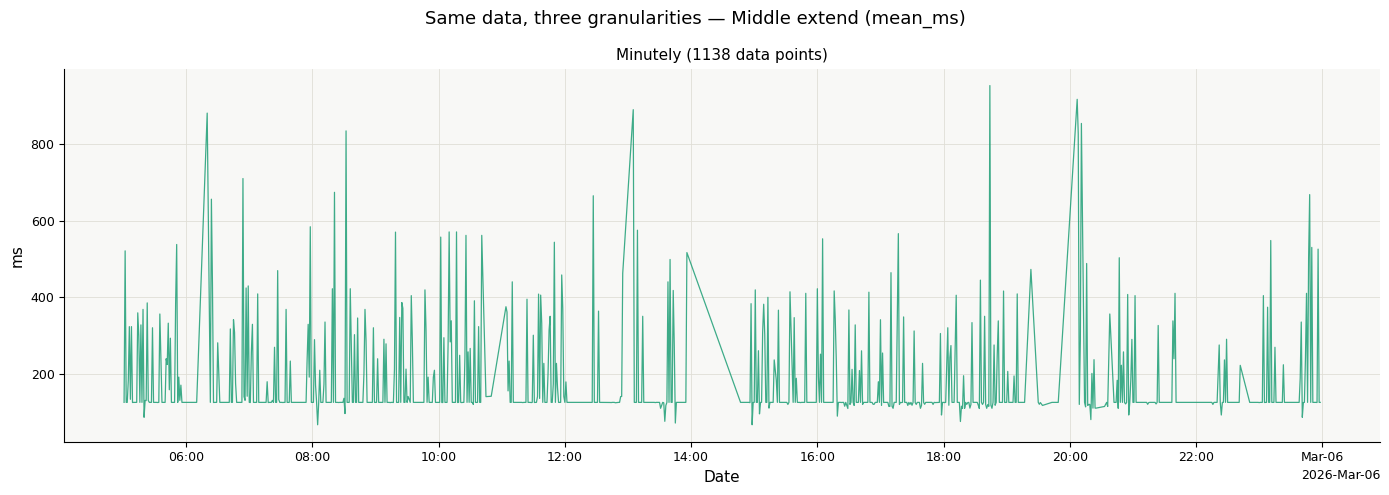


Data point counts:
  daily     :      1 points   (gaps before interp: 0.0%)
  hourly    :     19 points   (gaps before interp: 0.0%)
  minutely  :  1,138 points   (gaps before interp: 0.0%)


In [5]:
# ── PARAMETERS — change these ──────────────────────────────────────
CYL  = "Middle"
DIR  = "extend"
MET  = "mean_ms"
GRAN = "minutely"    # "daily" | "hourly" | "minutely"

GRANULARITIES = ["minutely"]      # change this to ["daily","hourly","minutely"]
# ───────────────────────────────────────────────────────────────────

import matplotlib.dates as mdates

fig, axes = plt.subplots(len(GRANULARITIES), 1, figsize=(14, 5*len(GRANULARITIES)), sharex=False)

# Make axes iterable even if there's only one subplot
if len(GRANULARITIES) == 1:
    axes = [axes]

fig.suptitle(f"Same data, three granularities — {CYL} {DIR} ({MET})", fontsize=13)

colors = {"daily": "#D85A30", "hourly": "#378ADD", "minutely": "#1D9E75"}

for ax, gran in zip(axes, GRANULARITIES):

    s = build_series(CYL, DIR, MET, gran, df=df_filtered)

    ax.plot(
        s.index,
        s.values,
        color=colors[gran],
        lw=0.9 if gran == "minutely" else 1.3,
        alpha=0.85
    )

    # Fix x-axis formatting
    locator = mdates.AutoDateLocator()
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(mdates.ConciseDateFormatter(locator))

    ax.set_title(f"{gran.capitalize()} ({len(s)} data points)", fontsize=11)
    ax.set_ylabel("ms")
    ax.yaxis.set_major_formatter(
        mticker.FuncFormatter(lambda v, _: f"{v:.0f}")
    )

axes[-1].set_xlabel("Date")

plt.tight_layout()
plt.show()

print("\nData point counts:")
for gran in ["daily","hourly","minutely"]:
    s = build_series(CYL, DIR, MET, gran, df=df_filtered)
    pct_gaps = s.isna().mean() * 100
    print(f"  {gran:10s}: {len(s):6,} points   (gaps before interp: {pct_gaps:.1f}%)")

In [37]:
train_start = '2026-03-05 16:00'
train_end   = '2026-03-05 18:00'
test_end    = '2026-03-05 18:30'

df_train = df_filtered[(df_filtered['datetime'] >= train_start) & (df_filtered['datetime'] < train_end)]
df_test  = df_filtered[(df_filtered['datetime'] >= train_end)   & (df_filtered['datetime'] < test_end)]

train_series = build_series(
    cylinder=CYL,
    direction=DIR,
    metric=MET,
    granularity=GRAN,
    df=df_train
)

test_series = build_series(
    cylinder=CYL,
    direction=DIR,
    metric=MET,
    granularity=GRAN,
    df=df_test
)



━━━  Plain-English Interpretation  ━━━

Series  : Middle__extend__mean_ms__minutely

[Stationarity]  The series is STATIONARY — it oscillates around a stable mean. No long-term drift was detected, so ARIMA can model it as-is.

[Model order]  ARIMA(1,0,1)
  p=1: The model uses the last 1 observation(s) to predict the next one.
  q=1: The model corrects for the last 1 prediction error(s).

[Forecast accuracy]  Weak — MAPE of 32.7%. This series may be too noisy or too short for ARIMA to model well. Consider more data or a different metric.
  MAE  = 59.277 ms   (average absolute miss)
  RMSE = 81.739 ms  (penalises large misses more)
  MAPE = 32.70%         (percentage miss, scale-free)

[What to do next]
  The series is stable. ARIMA should give reliable near-term forecasts.


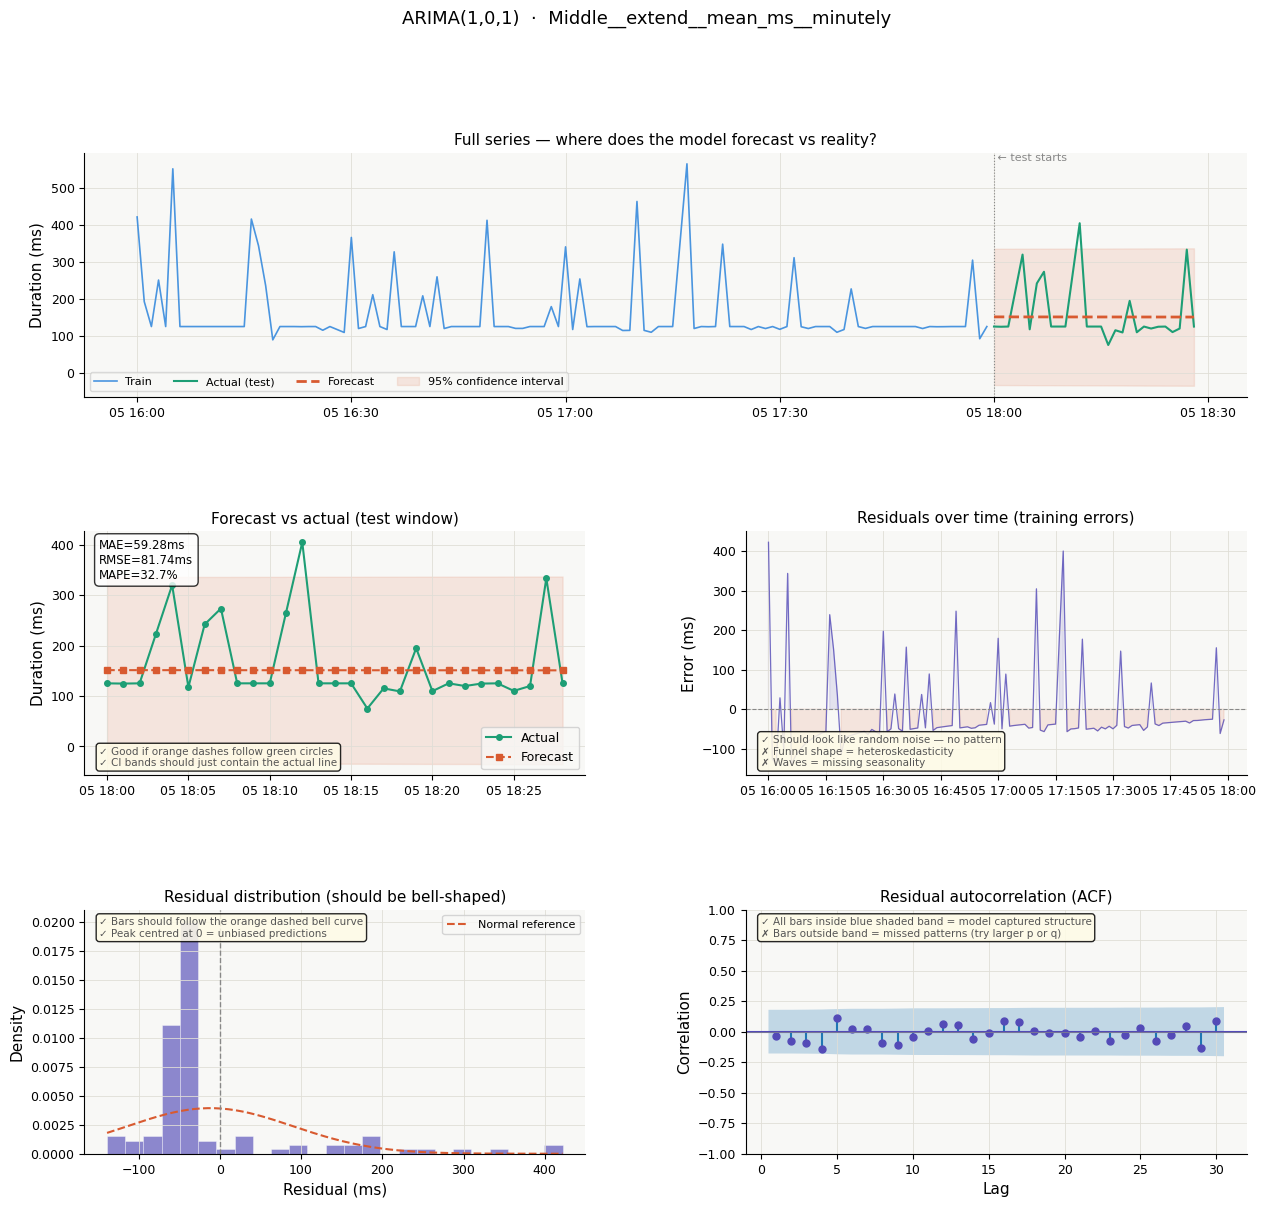

In [38]:
# ── PARAMETERS — tune these ────────────────────────────────────────
# CYL         = "Middle"
# DIR         = "retract"
# MET         = "mean_ms"   # "mean_ms" | "std_ms" | "p95_ms" | "slow_pct"
# GRAN        = "minutely"    # "daily" | "hourly" | "minutely"
# TEST_FRAC   = 0.15        # fraction of data to hold out as test

# ── auto_arima options (optional — leave as-is to let it auto-select) ─
MAX_P       = 10
MAX_Q       = 10
MAX_D       = 10
SEASONAL    = False       # True = also fit seasonal SARIMA terms
M           = 1           # seasonal period (e.g. 24 for daily cycle in hourly data)
CRITERION   = "aic"       # model selection: "aic" | "bic"
STEPWISE    = False        # True = fast; False = exhaustive (slow!)
VERBOSE     = False        # print auto_arima search log
# ───────────────────────────────────────────────────────────────────

r = run_arima(
    cylinder=CYL, direction=DIR, metric=MET, granularity=GRAN,
    train_series=train_series,
    test_series=test_series,
    # test_frac=TEST_FRAC,
    max_p=MAX_P, max_q=MAX_Q, max_d=MAX_D,
    seasonal=SEASONAL, m=M,
    information_criterion=CRITERION,
    stepwise=STEPWISE,
    verbose=VERBOSE,
)

show_results(r)
